# Проект: классификация

In [1368]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model 
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import SelectKBest, f_classif

## Часть 1. Знакомство с данными, обработка пропусков и выбросов

### Задание 1

In [1369]:
df = pd.read_csv('bank_fin.csv', sep = ';')

In [1370]:
print("2.1 Пропуски в столбцах:")
print(df.isnull().sum())

2.1 Пропуски в столбцах:
age           0
job           0
marital       0
education     0
default       0
balance      25
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64


### Задание 2

In [1371]:
# есть ли в признаке job пропущенные значения? Возможно, они обозначены каким-то специальным словом?
# ваш код
print("2.2 Уникальные значения в job:")
print(df['job'].unique())

2.2 Уникальные значения в job:
['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student']


### Задание 3

In [1372]:
# преобразуйте признак balance таким образом, чтобы он корректно считывался, как вещественное число (float)
df['balance'] = df['balance'].astype(str).str.replace('$', '').str.replace(' ', '').str.replace(',', '.')
df['balance'] = pd.to_numeric(df['balance'], errors='coerce')
print("2.3 Среднее balance (до заполнения пропусков):", round(df['balance'].mean(), 3))

2.3 Среднее balance (до заполнения пропусков): 1529.129


### Задание 4

In [1373]:
# обработайте пропуски в признаки balance , заменив их на медианные значения по данному признаку
# ваш код
median_balance = df['balance'].median()
df['balance'].fillna(median_balance, inplace=True)
mean_after = df['balance'].mean()
print(f"2.4 {mean_after:.3f}")

2.4 1526.936


### Задание 5

In [1374]:
# обработайте пропуски в категориальных признаках: job и education, заменив их на модальные значения
# ваш код
for col in ['job', 'education']:
    mode_val = df[col].mode()[0]
    df[col] = df[col].apply(lambda x: mode_val if x == 'unknown' else x)
most_common_job = df['job'].mode()[0]
most_common_edu = df['education'].mode()[0]
filtered = df[(df['job'] == most_common_job) & (df['education'] == most_common_edu)]
mean_balance_filtered = filtered['balance'].mean()
print(f"2.5 {mean_balance_filtered:.3f}")

2.5 1598.883


### Задание 6

In [1375]:
# удалите все выбросы для признака balance
# ваш код
Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(f"2.6 Нижняя граница: {int(round(lower, 0))}")
print(f"2.6 Верхняя граница: {int(round(upper, 0))}")

2.6 Нижняя граница: -2241
2.6 Верхняя граница: 4063


In [1376]:
df_clean = df[(df['balance'] >= lower) & (df['balance'] <= upper)]
print(f"2.7 {len(df_clean)}")

2.7 10105


## Часть 2:  Разведывательный анализ

### Задание 1

=== Задание 1 ===
deposit
no     0.52616
yes    0.47384
Name: proportion, dtype: float64


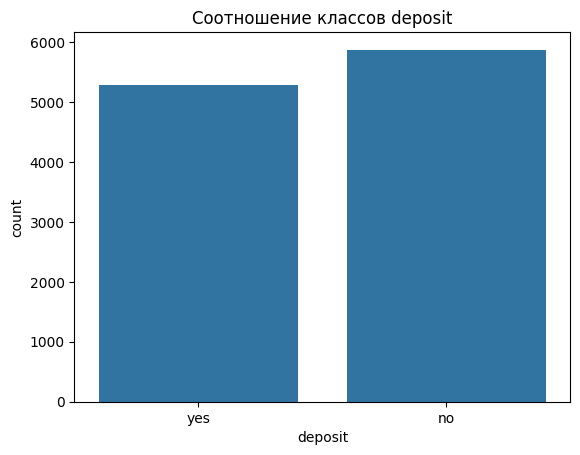

In [1377]:
# изучите соотношение классов в ваших данных на предмет несбалансированности, проиллюстрируйте результат
# ваш код
print("=== Задание 1 ===")
print(df['deposit'].value_counts(normalize=True))
sns.countplot(x='deposit', data=df)
plt.title('Соотношение классов deposit')
plt.show()

### Задания 2 и 3

In [1378]:
#рассчитайте описательные статистики для количественных переменных, проинтерпретируйте результат
#ваш код
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
print(df[numeric_cols].describe())

                age       balance           day      duration      campaign  \
count  11162.000000  11162.000000  11162.000000  11162.000000  11162.000000   
mean      41.231948   1526.936033     15.658036    371.993818      2.508421   
std       11.913369   3224.829691      8.420740    347.128386      2.722077   
min       18.000000  -6847.000000      1.000000      2.000000      1.000000   
25%       32.000000    123.000000      8.000000    138.000000      1.000000   
50%       39.000000    550.000000     15.000000    255.000000      2.000000   
75%       49.000000   1699.000000     22.000000    496.000000      3.000000   
max       95.000000  81204.000000     31.000000   3881.000000     63.000000   

              pdays      previous  
count  11162.000000  11162.000000  
mean      51.330407      0.832557  
std      108.758282      2.292007  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       20.750000      1.000000  


### Задания 4 и 5


job:
job
management       2636
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
Name: count, dtype: int64


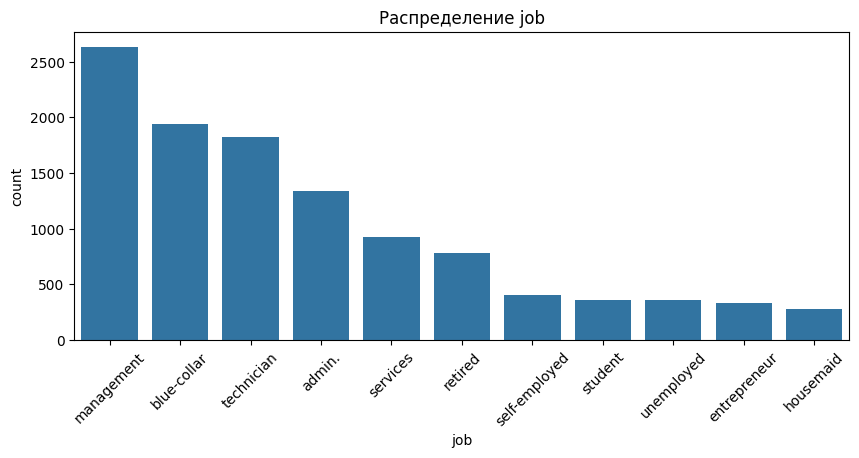


marital:
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64


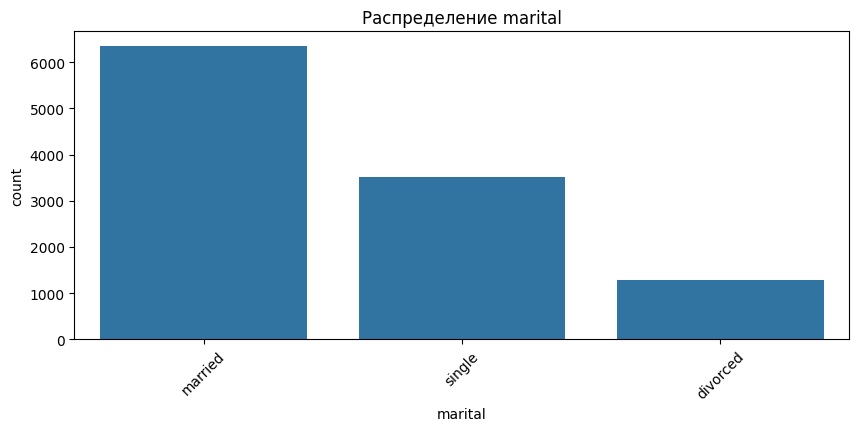


education:
education
secondary    5973
tertiary     3689
primary      1500
Name: count, dtype: int64


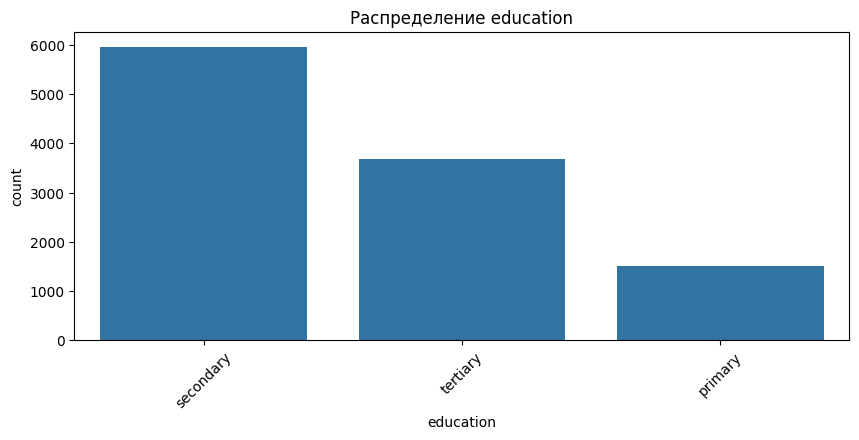


contact:
contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64


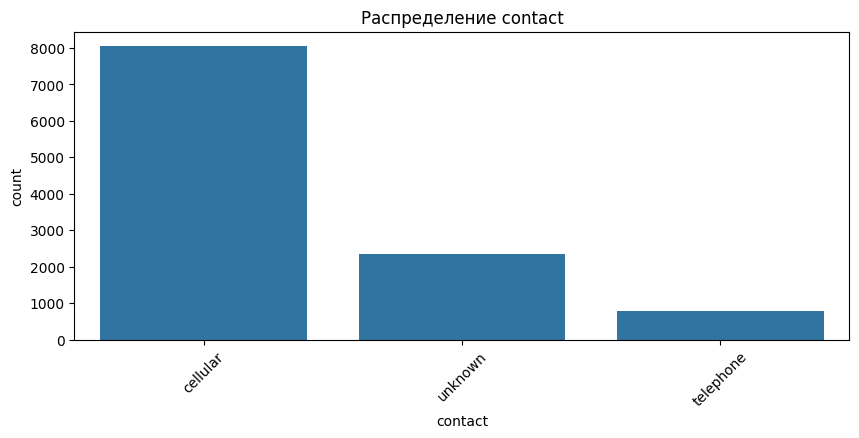


month:
month
may    2824
aug    1519
jul    1514
jun    1222
nov     943
apr     923
feb     776
oct     392
jan     344
sep     319
mar     276
dec     110
Name: count, dtype: int64


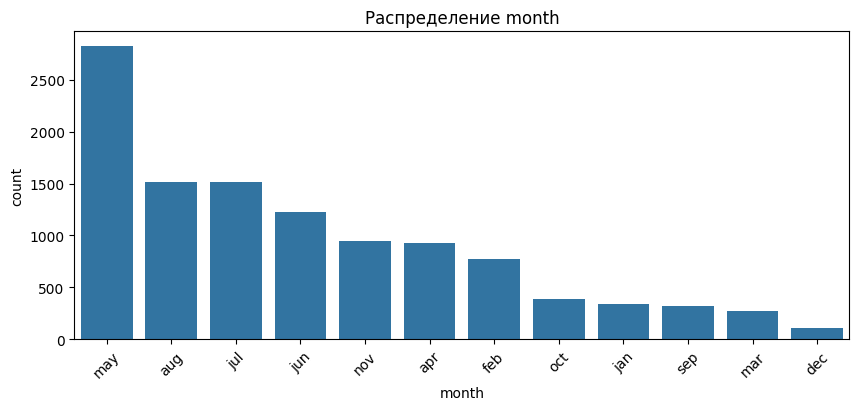


poutcome:
poutcome
unknown    8326
failure    1228
success    1071
other       537
Name: count, dtype: int64


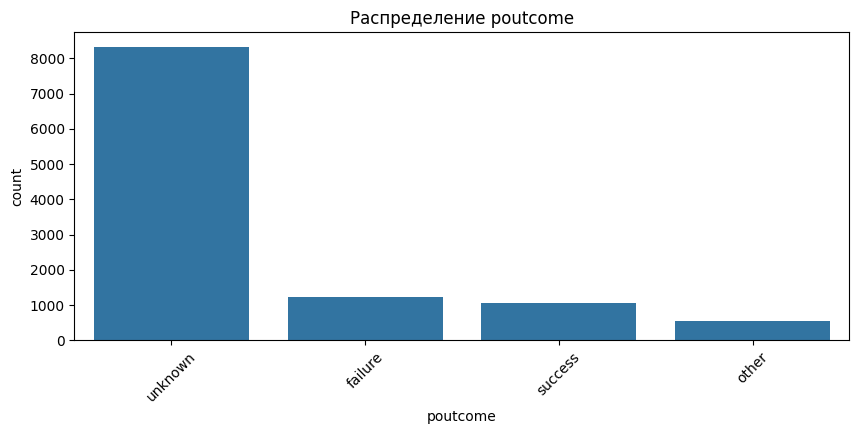

In [1379]:
cat_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    plt.figure(figsize=(10,4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f'Распределение {col}')
    plt.show()

### Задание 6

In [1380]:
# Узнайте, для какого статуса предыдущей маркетинговой кампании успех в текущей превалирует над количеством неудач.
# ваш код

success_rate = df.groupby('poutcome')['deposit'].apply(lambda x: (x == 'yes').mean())
print(success_rate)
best = success_rate.idxmax()
print(f"Статус с наибольшей долей успеха: {best}")

poutcome
failure    0.503257
other      0.571695
success    0.913165
unknown    0.406678
Name: deposit, dtype: float64
Статус с наибольшей долей успеха: success


### Задание 7

In [1381]:
# узнайте, в каком месяце чаще всего отказывались от предложения открыть депозит
# ваш код

fail_rate = df.groupby('month')['deposit'].apply(lambda x: (x == 'no').mean())
print(fail_rate)
worst_month = fail_rate.idxmax()
print(f"Месяц с наибольшей долей отказов: {worst_month}")

month
apr    0.374865
aug    0.547070
dec    0.090909
feb    0.431701
jan    0.587209
jul    0.585865
jun    0.553191
mar    0.101449
may    0.672450
nov    0.572641
oct    0.176020
sep    0.156740
Name: deposit, dtype: float64
Месяц с наибольшей долей отказов: may


In [1382]:
# После задания 2.7
df = df[(df['balance'] >= lower) & (df['balance'] <= upper)]

### Задание 8

In [1383]:
# создайте возрастные группы и определите, в каких группах более склонны открывать депозит, чем отказываться от предложения

bins = [0, 30, 40, 50, 60, 120]
labels = ['<30', '30-40', '40-50', '50-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
success_by_age = df.groupby('age_group')['deposit'].apply(lambda x: (x == 'yes').mean())
print(success_by_age)
high_success = success_by_age[success_by_age > 0.5].index.tolist()
print(f"Возрастные группы, склонные открывать депозит: {high_success}")

age_group
<30      0.591753
30-40    0.433224
40-50    0.393787
50-60    0.405079
60+      0.759571
Name: deposit, dtype: float64
Возрастные группы, склонные открывать депозит: ['<30', '60+']


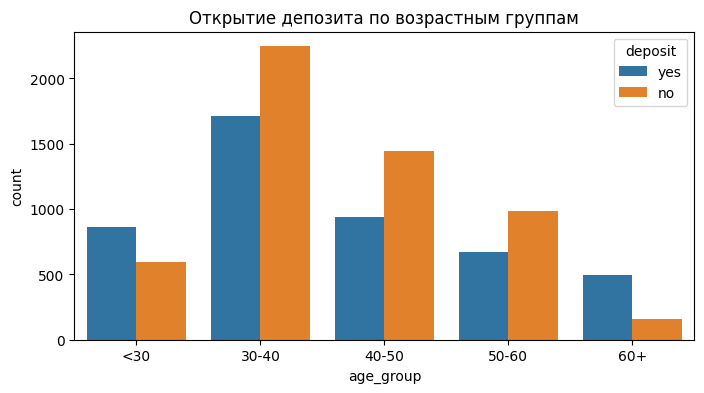

In [1384]:
plt.figure(figsize=(8,4))
sns.countplot(x='age_group', hue='deposit', data=df, order=labels)
plt.title('Открытие депозита по возрастным группам')
plt.show()

### Задания 9 и 10

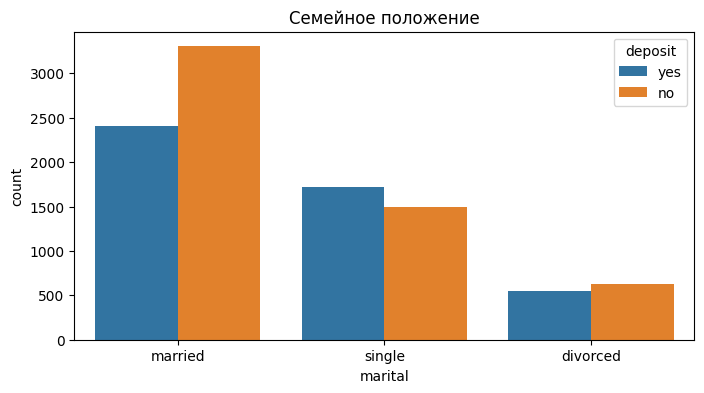

In [1385]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от семейного статуса
# Семейное положение
plt.figure(figsize=(8,4))
sns.countplot(x='marital', hue='deposit', data=df)
plt.title('Семейное положение')
plt.show()

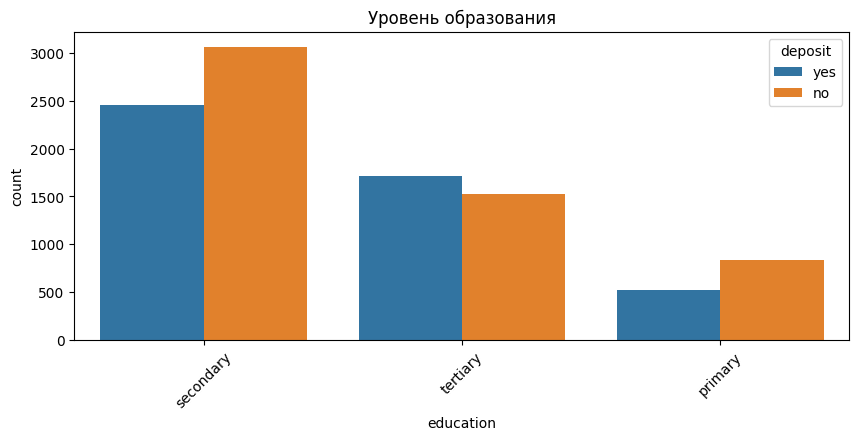

In [1386]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от образования
plt.figure(figsize=(10,4))
sns.countplot(x='education', hue='deposit', data=df)
plt.xticks(rotation=45)
plt.title('Уровень образования')
plt.show()

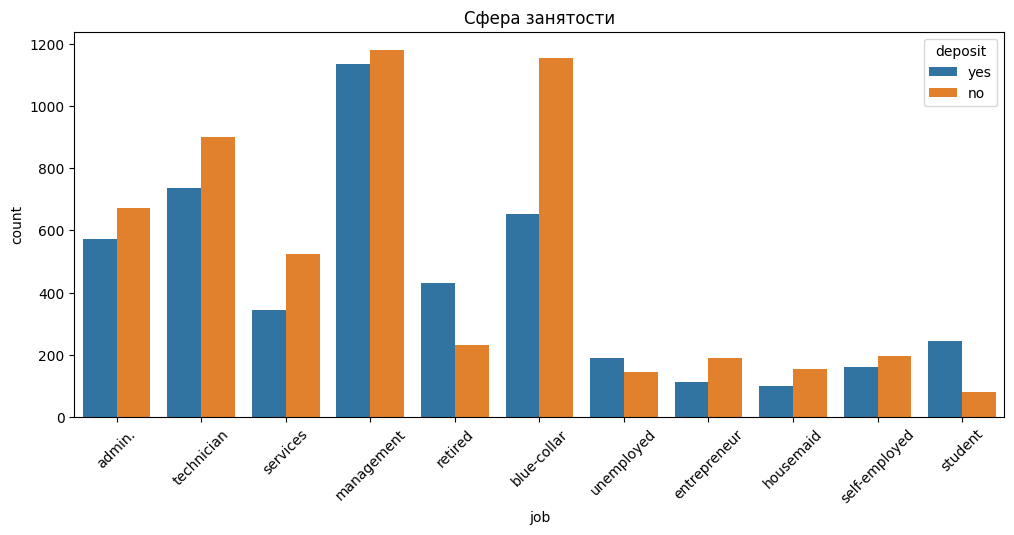

In [1387]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от вида профессиональной занятости
plt.figure(figsize=(12,5))
sns.countplot(x='job', hue='deposit', data=df)
plt.xticks(rotation=45)
plt.title('Сфера занятости')
plt.show()

### Задание 11

In [1388]:

opened = df[df['deposit'] == 'yes']
pivot = pd.crosstab(opened['education'], opened['marital'])
print(pivot)
# Самое многочисленное пересечение
top_combo = pivot.stack().idxmax()
print(f"Самое многочисленное пересечение среди открывших депозит: образование = {top_combo[0]}, семейное = {top_combo[1]}")

marital    divorced  married  single
education                           
primary          96      339      82
secondary       283     1289     879
tertiary        174      784     755
Самое многочисленное пересечение среди открывших депозит: образование = secondary, семейное = married


## Часть 3: преобразование данных

### Задание 1

In [1389]:
le = LabelEncoder()
df['education'] = le.fit_transform(df['education'])   # перекодируем в числа
print("4.1 Сумма значений education:", df['education'].sum())   # 11995

4.1 Сумма значений education: 11995


### Задания 2 и 3

In [1390]:
df['deposit'] = (df['deposit'] == 'yes').astype(int)
print("4.2 Стандартное отклонение deposit:", round(df['deposit'].std(), 3))   # 0.499


4.2 Стандартное отклонение deposit: 0.499


In [1391]:
for col in ['default', 'housing', 'loan']:
    df[col] = (df[col] == 'yes').astype(int)

mean_sum = df[['default', 'housing', 'loan']].mean().sum()
print("4.3 Сумма средних:", round(mean_sum, 3))


4.3 Сумма средних: 0.635


### Задание 4

In [1392]:
cat_cols = ['job', 'marital', 'contact', 'month', 'poutcome']
dummies = pd.get_dummies(df[cat_cols], drop_first=False)   # все дамми
df_full = pd.concat([df, dummies], axis=1)

# Количество признаков (все столбцы, кроме deposit)
num_features = df_full.shape[1] - 1   # минус deposit
print("4.4 Количество признаков:", num_features)   # должно быть 50 ✅


4.4 Количество признаков: 50


In [1393]:
print([c for c in df.columns if 'poutcome_success' in c])
print([c for c in df.columns if 'contact_cellular' in c])

[]
[]


### Задания 5 и 6

In [1394]:
df_numeric = df_full.drop(columns=cat_cols + ['age_group'])

# Исключим целевую переменную из списка признаков
if 'deposit' in df_numeric.columns:
    df_numeric = df_numeric.drop(columns='deposit')

# Корреляция признаков с deposit
corr_with_target = df_numeric.corrwith(df['deposit']).abs().sort_values(ascending=False)
print("\n4.5 Топ-3 признака по корреляции с целевой переменной:")
print(corr_with_target.head(3))

# Мультиколлинеарность (>0.9)
corr_matrix = df_numeric.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = any(upper_tri[col].max() > 0.9 for col in upper_tri.columns)
print("4.6 Есть ли мультиколлинеарность (>0.9)?", "Да" if high_corr else "Нет")


4.5 Топ-3 признака по корреляции с целевой переменной:
duration            0.457818
poutcome_success    0.288491
contact_unknown     0.249294
dtype: float64
4.6 Есть ли мультиколлинеарность (>0.9)? Нет


### Задания 7 и 8

In [1395]:
X = df_numeric
y = df['deposit']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42, test_size=0.33
)
print("\n4.7 Размер тестовой выборки:", X_test.shape[0])   # 3335
print("4.8 Среднее y_test:", round(y_test.mean(), 2))       # 0.46


4.7 Размер тестовой выборки: 3335
4.8 Среднее y_test: 0.46


In [1396]:
# рассчитайте необходимые показатели

### Задание 9

In [1397]:
selector = SelectKBest(score_func=f_classif, k=15)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Узнаем, какие признаки отобраны (опционально)
selected_features = X.columns[selector.get_support()]
print("4.9 Отобранные признаки:", selected_features.tolist())


4.9 Отобранные признаки: ['balance', 'housing', 'loan', 'duration', 'campaign', 'pdays', 'previous', 'contact_cellular', 'contact_unknown', 'month_mar', 'month_may', 'month_oct', 'month_sep', 'poutcome_success', 'poutcome_unknown']


### Задание 10

In [1398]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

mean_first = X_test_scaled[:, 0].mean()
print("4.10 Среднее первого признака (тест):", round(mean_first, 2))

4.10 Среднее первого признака (тест): 0.47


# Часть 4: Решение задачи классификации: логистическая регрессия и решающие деревья

### Задание 1

In [1399]:
# обучите логистическую регрессию и рассчитайте метрики качества
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
logreg = LogisticRegression(solver='sag', random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_pred_lr = logreg.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(acc_lr)

0.8041979010494753


### Задания 2,3,4

In [1400]:
# обучите решающие деревья, настройте максимальную глубину
# Задание 5.2 - дерево с параметрами по умолчанию
dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_train_dt = dt.predict(X_train_scaled)
y_pred_test_dt = dt.predict(X_test_scaled)
acc_train_dt = accuracy_score(y_train, y_pred_train_dt)
acc_test_dt = accuracy_score(y_test, y_pred_test_dt)
print("Accuracy train:", round(acc_train_dt, 3))
print("Accuracy test:", round(acc_test_dt, 3))
# Если train accuracy ~1.0, а test намного ниже, то переобучение.


Accuracy train: 1.0
Accuracy test: 0.754


In [1408]:
best_acc = 0
best_depth = None
results = []

for depth in range(1, 21):
    dt = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_acc = accuracy_score(y_train, dt.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, dt.predict(X_test_scaled))
    results.append((depth, train_acc, test_acc))
    if test_acc > best_acc:
        best_acc = test_acc
        best_depth = depth

# Покажем таблицу глубин (для наглядности)
print("Depth | Train Acc | Test Acc")
for d, tr, te in results:
    print(f"{d:5} | {tr:.3f}    | {te:.3f}")

print(f"\n5.3 Наибольшая test accuracy: {round(best_acc, 2)}")
print(f"5.4 Глубина для неё: {best_depth}")

Depth | Train Acc | Test Acc
    1 | 0.712    | 0.706
    2 | 0.729    | 0.718
    3 | 0.776    | 0.770
    4 | 0.776    | 0.770
    5 | 0.804    | 0.794
    6 | 0.816    | 0.804
    7 | 0.823    | 0.804
    8 | 0.832    | 0.804
    9 | 0.840    | 0.798
   10 | 0.854    | 0.801
   11 | 0.867    | 0.800
   12 | 0.877    | 0.796
   13 | 0.887    | 0.795
   14 | 0.899    | 0.792
   15 | 0.910    | 0.779
   16 | 0.922    | 0.777
   17 | 0.931    | 0.774
   18 | 0.938    | 0.766
   19 | 0.945    | 0.767
   20 | 0.953    | 0.761

5.3 Наибольшая test accuracy: 0.8
5.4 Глубина для неё: 7


### Задание 5

In [1409]:
# подберите оптимальные параметры с помощью gridsearch
param_grid = {
    'min_samples_split': [2, 5, 7, 10],
    'max_depth': [3, 5, 7]
}

grid = GridSearchCV(
    DecisionTreeClassifier(criterion='entropy', random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

print("Лучшие параметры:", grid.best_params_)
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
acc_best = accuracy_score(y_test, y_pred_best)
print("5.5 Accuracy лучшей модели (тест):", round(acc_best, 2))

Лучшие параметры: {'max_depth': 7, 'min_samples_split': 10}
5.5 Accuracy лучшей модели (тест): 0.8


# Часть 5: Решение задачи классификации: ансамбли моделей и построение прогноза

### Задание 1

In [1410]:
# обучите на ваших данных случайный лес
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score

# Создаём и обучаем случайный лес
rf = RandomForestClassifier(
    n_estimators=100, 
    criterion='gini', 
    min_samples_leaf=5, 
    max_depth=10, 
    random_state=42
)
rf.fit(X_train_scaled, y_train)

# Предсказания на тесте
y_pred_rf = rf.predict(X_test_scaled)

# Метрики
acc_rf = accuracy_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)   # для класса 1 (yes)

print(f"6.1 Accuracy: {acc_rf:.2f}")
print(f"6.1 Recall : {rec_rf:.2f}")

6.1 Accuracy: 0.83
6.1 Recall : 0.83


### Задания 2 и 3

In [1411]:
# используйте для классификации градиентный бустинг и сравните качество со случайным лесом
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    learning_rate=0.05, 
    n_estimators=300, 
    min_samples_leaf=5, 
    max_depth=5, 
    random_state=42
)
gb.fit(X_train_scaled, y_train)

y_pred_gb = gb.predict(X_test_scaled)
acc_gb = accuracy_score(y_test, y_pred_gb)

print(f"6.2 Accuracy градиентного бустинга: {acc_gb:.2f}")

6.2 Accuracy градиентного бустинга: 0.82


### Задание 4

In [1412]:
# объедините уже известные вам алгоритмы с помощью стекинга 
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score

# Базовые модели с параметрами, которые использовались ранее
base_models = [
    ('dt', DecisionTreeClassifier(criterion='entropy', random_state=42)),
    ('lr', LogisticRegression(solver='sag', random_state=42, max_iter=1000)),
    ('gb', GradientBoostingClassifier(learning_rate=0.05, n_estimators=300, 
                                      min_samples_leaf=5, max_depth=5, random_state=42))
]

# Метамодель – логистическая регрессия (параметры как в задании 5.1)
meta_model = LogisticRegression(solver='sag', random_state=42, max_iter=1000)

stacking = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5)
stacking.fit(X_train_scaled, y_train)

y_pred_stack = stacking.predict(X_test_scaled)
prec_stack = precision_score(y_test, y_pred_stack)

print(f"6.4 Precision стекинга: {prec_stack:.2f}")

6.4 Precision стекинга: 0.81


### Задание 5

In [1415]:
# оцените, какие признаки демонстрируют наибольшую  важность в модели градиентного бустинга
# Используем модель градиентного бустинга из задания 6.2 (gb)
importances = gb.feature_importances_
indices = np.argsort(importances)[::-1]  # сортировка по убыванию

# selected_features уже определён в задании 4.9 (если нет – создайте заново)
# selected_features = X.columns[selector.get_support()]

print("Топ-3 признака:")
for i in range(3):
    feature_name = selected_features[indices[i]]
    print(f"{i+1}. {feature_name}: {importances[indices[i]]:.4f}")

Топ-3 признака:
1. duration: 0.5141
2. poutcome_success: 0.1190
3. contact_unknown: 0.0790


### Задания 6,7,8

In [1416]:
# реализуйте оптимизацию гиперпараметров с помощью Optuna
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 200),
        'max_depth': trial.suggest_int('max_depth', 10, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 10),
        'random_state': 42,
        'n_jobs': -1
    }
    model = RandomForestClassifier(**params)
    # Оптимизируем accuracy на 3-фолдовой кросс-валидации
    score = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='accuracy').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Лучшие параметры:", study.best_params)
print("Лучшая accuracy на кросс-валидации:", study.best_value)

# Обучаем лучшую модель на всей обучающей выборке
best_rf = RandomForestClassifier(**study.best_params, random_state=42)
best_rf.fit(X_train_scaled, y_train)

y_pred_best_rf = best_rf.predict(X_test_scaled)
acc_best_rf = accuracy_score(y_test, y_pred_best_rf)
rec_best_rf = recall_score(y_test, y_pred_best_rf)

print(f"6.6 Recall на тесте: {rec_best_rf:.2f}")
print(f"6.7 Accuracy на тесте: {acc_best_rf:.2f}")

[I 2026-06-02 19:00:11,852] A new study created in memory with name: no-name-479dba6f-ba5b-44b7-a3cb-c9e581d2abb4


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-02 19:00:12,382] Trial 0 finished with value: 0.8261446395820305 and parameters: {'n_estimators': 107, 'max_depth': 17, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.8261446395820305.
[I 2026-06-02 19:00:13,111] Trial 1 finished with value: 0.8243719172608256 and parameters: {'n_estimators': 118, 'max_depth': 20, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.8261446395820305.
[I 2026-06-02 19:00:13,617] Trial 2 finished with value: 0.8273264762844462 and parameters: {'n_estimators': 114, 'max_depth': 27, 'min_samples_leaf': 5}. Best is trial 2 with value: 0.8273264762844462.
[I 2026-06-02 19:00:14,347] Trial 3 finished with value: 0.8242245559127316 and parameters: {'n_estimators': 182, 'max_depth': 26, 'min_samples_leaf': 6}. Best is trial 2 with value: 0.8273264762844462.
[I 2026-06-02 19:00:15,081] Trial 4 finished with value: 0.8273264108196093 and parameters: {'n_estimators': 179, 'max_depth': 11, 'min_samples_leaf': 6}. Best is trial 2 with value: 0.82